<a href="https://colab.research.google.com/github/borysovamaryna/revenue-and-cost/blob/main/Revenue_and_Cost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
%cd /content/drive/MyDrive/bq-results-20260407-175108-1775584499051

Mounted at /content/drive
/content/drive/MyDrive/Mate_homework


In [ ]:
import zipfile

with zipfile.ZipFile('dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset_folder')
    print(zip_ref.namelist())

['13. Final project/countries.csv', '13. Final project/products.csv', '13. Final project/events.csv']


In [ ]:
df_countries = pd.read_csv('dataset_folder/13. Final project/countries.csv')
df_products = pd.read_csv('dataset_folder/13. Final project/products.csv')
df_events = pd.read_csv('dataset_folder/13. Final project/events.csv')
df_countries.head()


,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia


In [ ]:
df_products.head()


,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


In [ ]:
df_events.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


Розглянувши дані в таблицях, ми бачимо, що головною є таблиця з events оскільки в ній найбільш повна інформація, а саме:
- колонка 	Order ID -  унікальний номер замовлення
- колонка Order Date  -  дата замовлення
- колонка Ship Date - дата відвантаження
- колонка Order Priority	 -  пріоритентність замовлення
- колонка Country Code - код країни, відповідає колонці alpha-3	з таблиці countries, поєднавши дані таблиці ми зможемо проводити аналіз в розрізі країн, регіонів і субрегіонів.
- колонка Product ID -  унікальний номер товару і по цій колонці ми можемо доєднати до неї таблицю products, відповідником буде колонка id, і далі зможемо робити аналіз в розрізі категорій продукції
- колонка Sales Channel	 - вказує спосіб продажу онлайн чи офлайн магазин
- колонка Units Sold - вказує кількість товару в замовленні
- колонка Unit Price - вказує ціну товарів
- колонка Unit Cost - вказує витрати, повязану з реалізацією одиниці товару

також вважаю за доцільне перейменувати стовпці за правилом Snake Case, оскільки так буде зручніше для роботи

In [ ]:
df_events.columns = df_events.columns.str.lower().str.replace(" ", "_")
df_countries.columns = df_countries.columns.str.lower().str.replace("-", "_")

In [ ]:
df_events.isna().sum()

,0
order_id,0
order_date,0
ship_date,0
order_priority,0
country_code,82
product_id,0
sales_channel,0
units_sold,2
unit_price,0
unit_cost,0


In [ ]:
df_events.isna().sum() / df_events.shape[0] * 100

,0
order_id,0.000000
order_date,0.000000
ship_date,0.000000
order_priority,0.000000
country_code,6.165414
product_id,0.000000
sales_channel,0.000000
units_sold,0.150376
unit_price,0.000000
unit_cost,0.000000


In [ ]:
df_countries.isna().sum() / df_countries.shape[0] * 100

,0
name,0.000000
alpha_2,0.401606
alpha_3,0.000000
region,0.401606
sub_region,0.401606


In [ ]:
df_products.isna().sum()

,0
id,0
item_type,0


Розглянувши кількість пропущених значень ми бачимо, що в таблиці events, є 2 стовпці з пропущеними значеннями, а саме код країни та кількість продажів. Оскільки код країни пропущений в приблизно 6% значень, вважаю що доцільно буде його замінити на значення "unknown", і далі використовувати дані для аналізу. При цьому ми бачимо, що в колонці з продажами пропущено 2 значення, оскільки це складає менше 0,2% від загальної кількості даних я вважаю, що ці дані ми можемо видалити і на загальний аналіз це не вплине.

В таблиці products пропущених даних не знайдено, тому коригувань на разі вона не потребує.

беручи до уваги інформацію з таблиці countriesб ми бачимо що є пропущене значення в одному з рядків, оскільки дана табличка є додатковою вважаю, що можемо не редагувати її

In [ ]:
df_events = df_events.dropna(subset=["units_sold"])
df_events["country_code"] = df_events["country_code"].fillna("unknown")


In [ ]:
df_events.isna().sum()

,0
order_id,0
order_date,0
ship_date,0
order_priority,0
country_code,0
product_id,0
sales_channel,0
units_sold,0
unit_price,0
unit_cost,0


In [ ]:
df_countries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha_2     248 non-null    object
 2   alpha_3     249 non-null    object
 3   region      248 non-null    object
 4   sub_region  248 non-null    object
dtypes: object(5)
memory usage: 9.9+ KB


In [ ]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


In [ ]:
df_events.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        1328 non-null   int64  
 1   order_date      1328 non-null   object 
 2   ship_date       1328 non-null   object 
 3   order_priority  1328 non-null   object 
 4   country_code    1328 non-null   object 
 5   product_id      1328 non-null   int64  
 6   sales_channel   1328 non-null   object 
 7   units_sold      1328 non-null   float64
 8   unit_price      1328 non-null   float64
 9   unit_cost       1328 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 114.1+ KB


In [ ]:
df_events['order_date'] = pd.to_datetime(df_events['order_date'])
df_events['ship_date'] = pd.to_datetime(df_events['ship_date'])
df_events.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        1328 non-null   int64         
 1   order_date      1328 non-null   datetime64[ns]
 2   ship_date       1328 non-null   datetime64[ns]
 3   order_priority  1328 non-null   object        
 4   country_code    1328 non-null   object        
 5   product_id      1328 non-null   int64         
 6   sales_channel   1328 non-null   object        
 7   units_sold      1328 non-null   float64       
 8   unit_price      1328 non-null   float64       
 9   unit_cost       1328 non-null   float64       
dtypes: datetime64[ns](2), float64(3), int64(2), object(3)
memory usage: 114.1+ KB


In [ ]:
df_events[df_events.duplicated(keep=False)]

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost


In [ ]:
df_events["country_code"] = (df_events["country_code"].str.strip().str.upper())
df_events["sales_channel"] = (df_events["sales_channel"].str.strip().str.lower())
df_events["order_priority"] = (df_events["order_priority"].str.strip().str.upper())
df_events[df_events.duplicated(keep=False)]


,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost


In [ ]:
df_events.describe(include="all")

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost
count,1.328000e+03,1328,1328,1328,1328,1328.000000,1328,1328.000000,1328.000000,1328.000000
unique,NaN,NaN,NaN,4,46,NaN,2,NaN,NaN,NaN
top,NaN,NaN,NaN,M,UNKNOWN,NaN,offline,NaN,NaN,NaN
freq,NaN,NaN,NaN,353,82,NaN,665,NaN,NaN,NaN
mean,5.416231e+08,2013-10-11 22:28:54.939759104,2013-11-05 17:22:02.891566336,NaN,NaN,5787.775602,NaN,4952.201807,264.913245,187.211521
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,NaN,NaN,1270.000000,NaN,2.000000,9.330000,6.920000
25%,3.213291e+08,2011-12-14 06:00:00,2012-01-02 00:00:00,NaN,NaN,3127.000000,NaN,2356.750000,81.730000,35.840000
50%,5.399925e+08,2013-10-15 12:00:00,2013-11-05 12:00:00,NaN,NaN,5988.000000,NaN,4962.000000,154.060000,97.440000
75%,7.547357e+08,2015-08-29 12:00:00,2015-10-04 18:00:00,NaN,NaN,8681.000000,NaN,7459.500000,437.200000,263.330000
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,NaN,NaN,8969.000000,NaN,9999.000000,668.270000,524.960000


In [ ]:
df_countries = df_countries.rename(columns={"alpha_3": "country_code"})
df_products = df_products.rename(columns={"id": "product_id"})
df_countries["country_code"] = (df_countries["country_code"].str.strip().str.upper())

In [ ]:
sales_data_1 = pd.merge(df_events, df_countries, on="country_code", how="left")
sales_data_1.head()


,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,name,alpha_2,region,sub_region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,online,650.0,205.70,117.11,Norway,NO,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,offline,1993.0,205.70,117.11,Serbia,RS,Europe,Southern Europe
2,101025998,2014-07-18,2014-08-11,M,UNKNOWN,7940,online,4693.0,668.27,502.54,NaN,NaN,NaN,NaN
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,online,1171.0,109.28,35.84,Montenegro,ME,Europe,Southern Europe
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,offline,7648.0,47.45,31.79,Serbia,RS,Europe,Southern Europe


In [ ]:
sales_data = pd.merge(sales_data_1, df_products, on="product_id", how="left")
sales_data.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,name,alpha_2,region,sub_region,item_type
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,online,650.0,205.70,117.11,Norway,NO,Europe,Northern Europe,Cereal
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,offline,1993.0,205.70,117.11,Serbia,RS,Europe,Southern Europe,Cereal
2,101025998,2014-07-18,2014-08-11,M,UNKNOWN,7940,online,4693.0,668.27,502.54,NaN,NaN,NaN,NaN,Household
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,online,1171.0,109.28,35.84,Montenegro,ME,Europe,Southern Europe,Clothes
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,offline,7648.0,47.45,31.79,Serbia,RS,Europe,Southern Europe,Beverages


In [ ]:
sales_data = sales_data.rename(columns={"item_type": "category"})
sales_data = sales_data.rename(columns={"name": "country"})
sales_data = sales_data.rename(columns={"units_sold": "sold"})
sales_data = sales_data.rename(columns={"unit_price": "price"})
sales_data = sales_data.rename(columns={"unit_cost": "cost"})


In [ ]:
sales_data["country"] = sales_data["country"].fillna("UNKNOWN")
sales_data["region"] = sales_data["region"].fillna("UNKNOWN")
sales_data["sub_region"] = sales_data["sub_region"].fillna("UNKNOWN")
sales_data.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,sold,price,cost,country,alpha_2,region,sub_region,category
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,online,650.0,205.70,117.11,Norway,NO,Europe,Northern Europe,Cereal
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,offline,1993.0,205.70,117.11,Serbia,RS,Europe,Southern Europe,Cereal
2,101025998,2014-07-18,2014-08-11,M,UNKNOWN,7940,online,4693.0,668.27,502.54,UNKNOWN,NaN,UNKNOWN,UNKNOWN,Household
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,online,1171.0,109.28,35.84,Montenegro,ME,Europe,Southern Europe,Clothes
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,offline,7648.0,47.45,31.79,Serbia,RS,Europe,Southern Europe,Beverages


In [ ]:
sales_data["total_revenue"] = sales_data["sold"] * sales_data["price"]
sales_data["total_cost"] = sales_data["sold"] * sales_data["cost"]
sales_data["total_profit"] = sales_data["total_revenue"] - sales_data["total_cost"]
sales_data.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,sold,price,cost,country,alpha_2,region,sub_region,category,total_revenue,total_cost,total_profit
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,online,650.0,205.70,117.11,Norway,NO,Europe,Northern Europe,Cereal,133705.00,76121.50,57583.50
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,offline,1993.0,205.70,117.11,Serbia,RS,Europe,Southern Europe,Cereal,409960.10,233400.23,176559.87
2,101025998,2014-07-18,2014-08-11,M,UNKNOWN,7940,online,4693.0,668.27,502.54,UNKNOWN,NaN,UNKNOWN,UNKNOWN,Household,3136191.11,2358420.22,777770.89
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,online,1171.0,109.28,35.84,Montenegro,ME,Europe,Southern Europe,Clothes,127966.88,41968.64,85998.24
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,offline,7648.0,47.45,31.79,Serbia,RS,Europe,Southern Europe,Beverages,362897.60,243129.92,119767.68


In [ ]:
order_count = sales_data["order_id"].count()
print(f"Загальна кількість замовлень дорівнює: {order_count}")
sum_revenue = sales_data["total_revenue"].sum()
print(f"Загальний дохід складає: {sum_revenue}")
sum_cost = sales_data["total_cost"].sum()
print(f"Загальні витрати склали: {sum_cost}")
sum_profit = sales_data["total_profit"].sum()
print(f"Загальний прибуток склав: {sum_profit}")
country_count = len(sales_data['country'].unique()) - 1 #(-1) оскільки ми знаємо, що є невідоме значення по країнам
print(f"Кількість охоплених країн: {country_count}")
category_count = len(sales_data['category'].unique())
print(f"Кількість категорій, в розрізі яких проводилась реалізація продукції: {category_count} ")

Загальна кількість замовлень дорівнює: 1328
Загальний дохід складає: 1702129408.21
Загальні витрати склали: 1200694949.21
Загальний прибуток склав: 501434459.0
Кількість охоплених країн: 45
Кількість категорій, в розрізі яких проводилась реалізація продукції: 12 


In [ ]:
pivot_table_by_category = pd.pivot_table(sales_data, values=["total_cost", "total_revenue", "total_profit"], index="category", aggfunc="mean")
print(pivot_table_by_category)

                   total_cost   total_profit  total_revenue
category                                                   
Baby Food        8.009517e+05  481616.046071   1.282568e+06
Beverages        1.610868e+05   79352.584959   2.404393e+05
Cereal           5.294793e+05  400534.312136   9.300136e+05
Clothes          2.018594e+05  413631.565714   6.154910e+05
Cosmetics        1.231855e+06  813362.334825   2.045218e+06
Fruits           3.655688e+04   12731.513571   4.928839e+04
Household        2.280853e+06  752190.379072   3.033043e+06
Meat             1.758403e+06  275797.600000   2.034200e+06
Office Supplies  2.636072e+06  633960.782520   3.270032e+06
Personal Care    2.772247e+05  122591.321754   3.998160e+05
Snacks           4.637009e+05  262402.159223   7.261030e+05
Vegetables       4.646555e+05  322596.515088   7.872520e+05


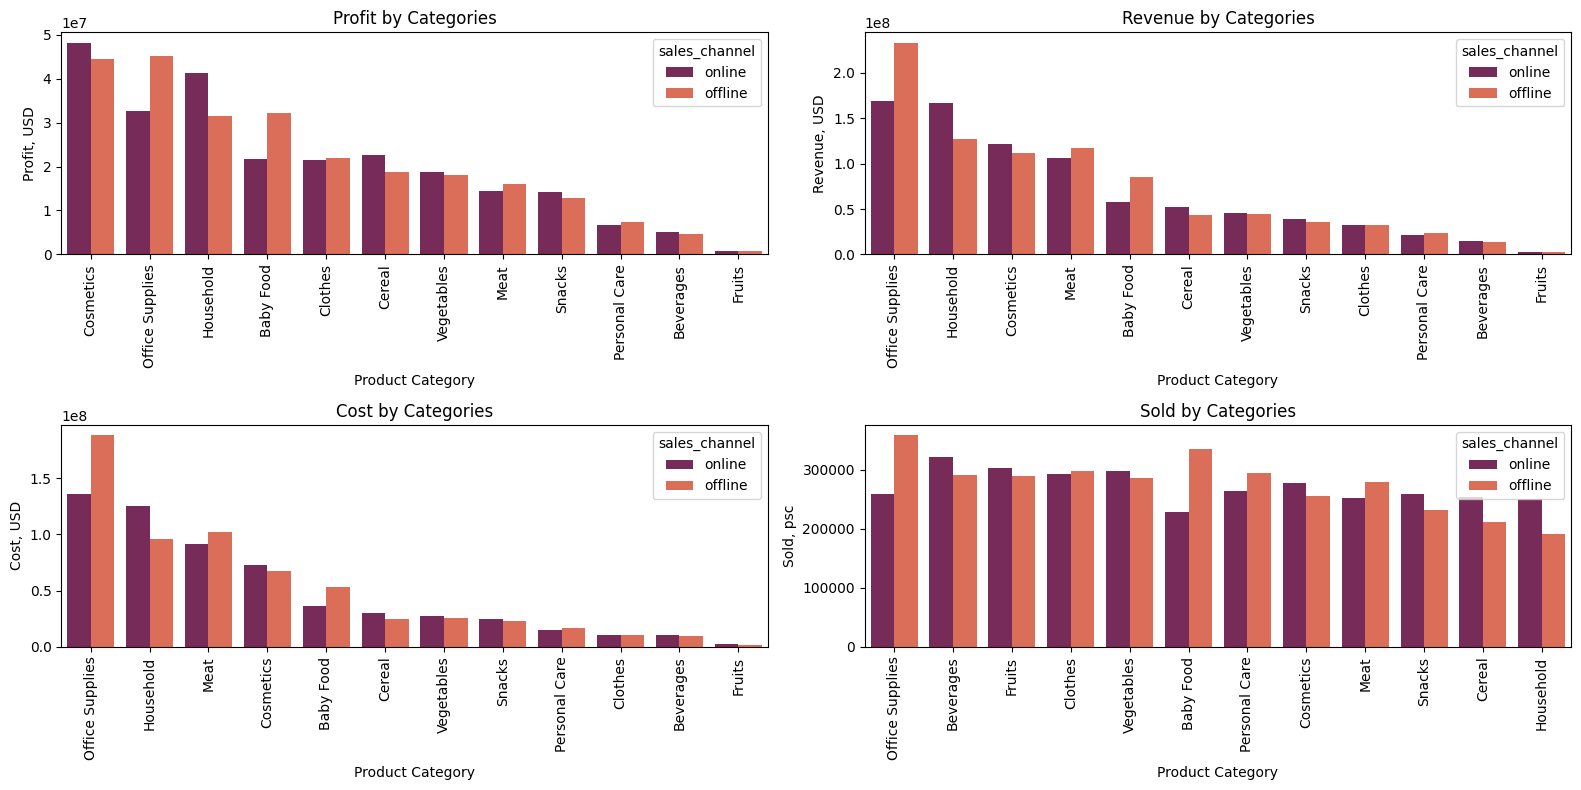

In [ ]:
# Create a figure with 2 rows and 2 columns of subplots
fig, ax = plt.subplots(2, 2, figsize=(16, 8))

#First subplot
order_category_1 = sales_data.groupby('category')['total_profit'].sum().sort_values(ascending = False).index
sns.barplot(
    x="category",
    y="total_profit",
    data=sales_data,
    estimator=np.sum,
    errorbar=None,
    hue="sales_channel",
    order=order_category_1,
    palette="rocket",
    ax=ax[0, 0]
    )
ax[0, 0].set_title("Profit by Categories")
ax[0, 0].set_xlabel("Product Category")
ax[0, 0].set_ylabel("Profit, USD")
ax[0, 0].tick_params(axis='x', rotation=90)

# Second subplot
order_category_2 = sales_data.groupby('category')['total_revenue'].sum().sort_values(ascending = False).index
sns.barplot(
    x="category",
    y="total_revenue",
    data=sales_data,
    estimator=np.sum,
    errorbar=None,
    hue="sales_channel",
    order=order_category_2,
    palette="rocket",
    ax=ax[0, 1]
    )
ax[0, 1].set_title("Revenue by Categories")
ax[0, 1].set_xlabel("Product Category")
ax[0, 1].set_ylabel("Revenue, USD")
ax[0, 1].tick_params(axis='x', rotation=90)

# Third subplot
order_category_3 = sales_data.groupby('category')['total_cost'].sum().sort_values(ascending = False).index
sns.barplot(
    x="category",
    y="total_cost",
    data=sales_data,
    estimator=np.sum,
    errorbar=None,
    order=order_category_3,
    hue="sales_channel",
    palette="rocket",
    ax=ax[1, 0]
    )
ax[1, 0].set_title("Cost by Categories")
ax[1, 0].set_xlabel("Product Category")
ax[1, 0].set_ylabel("Cost, USD")
ax[1, 0].tick_params(axis='x', rotation=90)

# Fourth subplot
order_category_4 = sales_data.groupby('category')['sold'].sum().sort_values(ascending = False).index
sns.barplot(
    x="category",
    y="sold",
    data=sales_data,
    estimator=np.sum,
    errorbar=None,
    order=order_category_4,
    hue="sales_channel",
    palette="rocket",
    ax=ax[1, 1]
    )
ax[1, 1].set_title("Sold by Categories")
ax[1, 1].set_xlabel("Product Category")
ax[1, 1].set_ylabel("Sold, psc")
ax[1, 1].tick_params(axis='x', rotation=90)

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

# Висновок до графіків
1. Найбільший прибуток приносять такі категорії: Побутова техніка, Офісне приладдя та Косметика. При цьому слід зазначити, що при продажу побутової техніки та косметики ми отримуємо більше прибутку при онлайн торгівлі, а от при продажу офісного приладдя - офлан. Найменше прибутку нам приносять такі категорії, як: Одяг, Напої та Фрукти.
2. Розглянувши показники доходу по категоріям  ми бачимо, що найбільше доходу приносять такі категоріх як Побутова техніка та Офісне приладдя, розподіл доходності в залежності від способу оплати такий же, як і при прибутку в даних категоріях. Найменше доходу приносять такі категорії, як:Соки та Фрукти.
3. Беручи до уваги витрати, ми бачимо, що найбільшими витратами є витрати в таких категоріях, як: Офісне приладдя та Побутова техніка.
4. По кількості продажів ми бачимо, що  найбільше продаються Офісне приладдя та Соки, при цьому слід зазначити, що кількість продажів не має явних перекосів і товари по категоріям продаються більш менш рівномірно
Отже, беручи до уваги все вищеперераховане ми можемо сказати, що від кількості проданої продукції прибуток нашої компанії не залежить. Також ми бачимо, що графіки по Доходності і витратах майже симетричні, а саме пропорційність доходів такаж як і витрат, але якщо звернути увагу на прибутки по категоріям, ми бачимо, що Косметика, Дитяче харчування, Одяг та Злаки не є лідерами в доходах, саме тому можемо сказати, що прибутковими є не лише Побутова техніка та Офісне приладдя, а й ці категорії


/tmp/ipykernel_1252/543087649.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1252/543087649.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1252/543087649.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1252/543087649.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


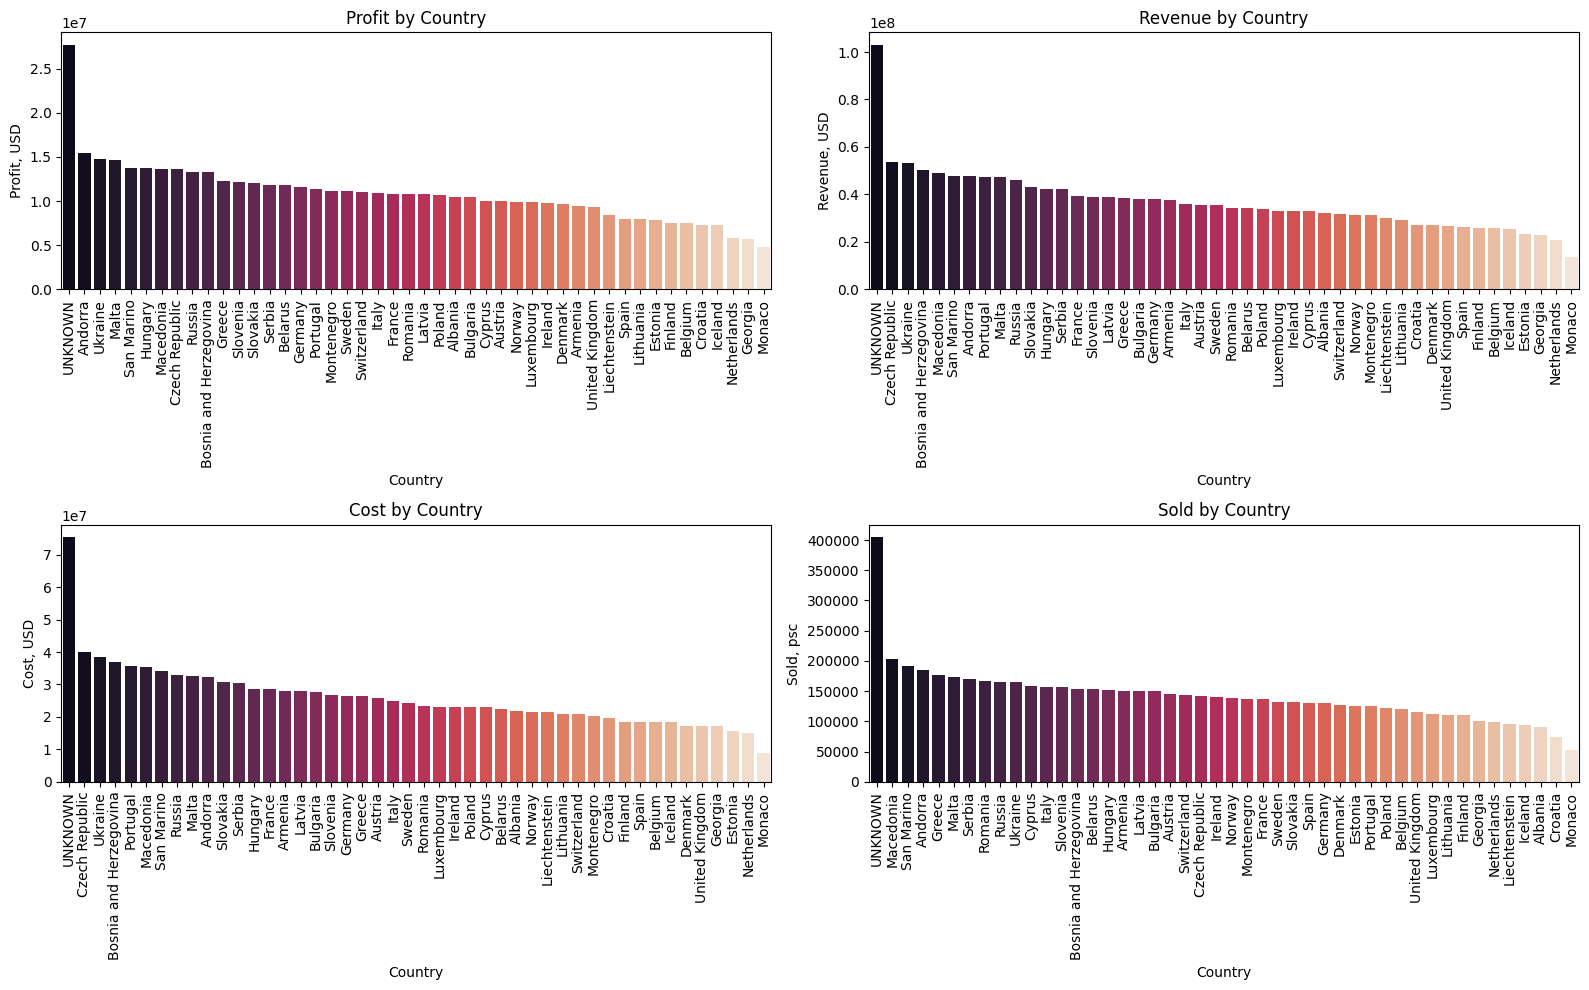

In [ ]:
# Create a figure with 2 rows and 2 columns of subplots
fig, ax = plt.subplots(2, 2, figsize=(16, 10))

#First subplot
order_country_1 = sales_data.groupby('country')['total_profit'].sum().sort_values(ascending = False).index
sns.barplot(
    x="country",
    y="total_profit",
    data=sales_data,
    estimator=np.sum,
    errorbar=None,
    order=order_country_1,
    palette="rocket",
    ax=ax[0, 0]
    )
ax[0, 0].set_title("Profit by Country")
ax[0, 0].set_xlabel("Country")
ax[0, 0].set_ylabel("Profit, USD")
ax[0, 0].tick_params(axis='x', rotation=90)

# Second subplot
order_country_2 = sales_data.groupby('country')['total_revenue'].sum().sort_values(ascending = False).index
sns.barplot(
    x="country",
    y="total_revenue",
    data=sales_data,
    estimator=np.sum,
    errorbar=None,
    order=order_country_2,
    palette="rocket",
    ax=ax[0, 1]
    )
ax[0, 1].set_title("Revenue by Country")
ax[0, 1].set_xlabel("Country")
ax[0, 1].set_ylabel("Revenue, USD")
ax[0, 1].tick_params(axis='x', rotation=90)

# Third subplot
order_country_3 = sales_data.groupby('country')['total_cost'].sum().sort_values(ascending = False).index
sns.barplot(
    x="country",
    y="total_cost",
    data=sales_data,
    estimator=np.sum,
    errorbar=None,
    order=order_country_3,
    palette="rocket",
    ax=ax[1, 0]
    )
ax[1, 0].set_title("Cost by Country")
ax[1, 0].set_xlabel("Country")
ax[1, 0].set_ylabel("Cost, USD")
ax[1, 0].tick_params(axis='x', rotation=90)

# Fourth subplot
order_country_4 = sales_data.groupby('country')['sold'].sum().sort_values(ascending = False).index
sns.barplot(
    x="country",
    y="sold",
    data=sales_data,
    estimator=np.sum,
    errorbar=None,
    order=order_country_4,
    palette="rocket",
    ax=ax[1, 1]
    )
ax[1, 1].set_title("Sold by Country")
ax[1, 1].set_xlabel("Country")
ax[1, 1].set_ylabel("Sold, psc")
ax[1, 1].tick_params(axis='x', rotation=90)

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

# Висновок до графіків:
Розглянувши графіки по доходу, витратам, прибуткам та продажам в розрізі країн ми бачимо, що графіки являються майже симетричними між собою. Тобто можемо сказати, що всі показники являються найбільшими при продажах де країна не була вказана, найменшими є в Монако. Далі серед країн лідерів є Мальта, Чехія, Україна, Ардорра, СанМаріно, Угорщина та Боснія і Герцоговина. Серед країн з найменшими продажами є Грузія, Нідерланди, Естонія та Хорватія.

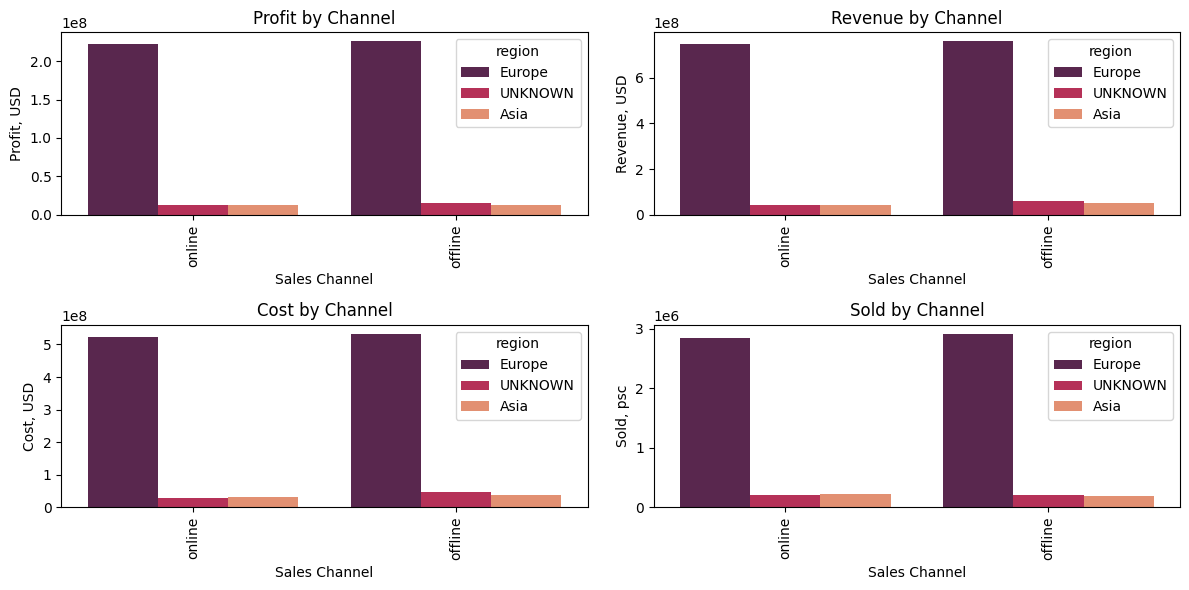

In [ ]:
# Create a figure with 2 rows and 2 columns of subplots
fig, ax = plt.subplots(2, 2, figsize=(12, 6))

#First subplot
sns.barplot(
    x="sales_channel",
    y="total_profit",
    data=sales_data,
    estimator=np.sum,
    errorbar=None,
    hue="region",
    palette="rocket",
    ax=ax[0, 0]
    )
ax[0, 0].set_title("Profit by Channel")
ax[0, 0].set_xlabel("Sales Channel")
ax[0, 0].set_ylabel("Profit, USD")
ax[0, 0].tick_params(axis='x')

# Second subplot
sns.barplot(
    x="sales_channel",
    y="total_revenue",
    data=sales_data,
    estimator=np.sum,
    errorbar=None,
    hue="region",
    palette="rocket",
    ax=ax[0, 1]
    )
ax[0, 1].set_title("Revenue by Channel")
ax[0, 1].set_xlabel("Sales Channel")
ax[0, 1].set_ylabel("Revenue, USD")
ax[0, 1].tick_params(axis='x')

# Third subplot
sns.barplot(
    x="sales_channel",
    y="total_cost",
    data=sales_data,
    estimator=np.sum,
    errorbar=None,
    hue="region",
    palette="rocket",
    ax=ax[1, 0]
    )
ax[1, 0].set_title("Cost by Channel")
ax[1, 0].set_xlabel("Sales Channel")
ax[1, 0].set_ylabel("Cost, USD")
ax[1, 0].tick_params(axis='x')

# Fourth subplot
sns.barplot(
    x="sales_channel",
    y="sold",
    data=sales_data,
    estimator=np.sum,
    errorbar=None,
    hue="region",
    palette="rocket",
    ax=ax[1, 1]
    )
ax[1, 1].set_title("Sold by Channel")
ax[1, 1].set_xlabel("Sales Channel")
ax[1, 1].set_ylabel("Sold, psc")
ax[1, 1].tick_params(axis='x')

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

# Висновок до графіків
Розглянувши графіки ми бачимо, що найбільше продажів ми маємо онлайн, при цьому найбільше прибутку також маємо онлайн. Слід також зазначити, що реалізація продукції відбувається в країнах Європи, і лише мінімальна частина продається в країнах Азії.

In [ ]:
sales_data["processing_period"] = sales_data["ship_date"] - sales_data["order_date"]
sales_data.head()
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype          
---  ------             --------------  -----          
 0   order_id           1328 non-null   int64          
 1   order_date         1328 non-null   datetime64[ns] 
 2   ship_date          1328 non-null   datetime64[ns] 
 3   order_priority     1328 non-null   object         
 4   country_code       1328 non-null   object         
 5   product_id         1328 non-null   int64          
 6   sales_channel      1328 non-null   object         
 7   sold               1328 non-null   float64        
 8   price              1328 non-null   float64        
 9   cost               1328 non-null   float64        
 10  country            1328 non-null   object         
 11  alpha_2            1246 non-null   object         
 12  region             1328 non-null   object         
 13  sub_region         1328 non-null   object       

In [ ]:
sales_data["processing_period_days"] = (sales_data["processing_period"].dt.total_seconds() / 86400)
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype          
---  ------                  --------------  -----          
 0   order_id                1328 non-null   int64          
 1   order_date              1328 non-null   datetime64[ns] 
 2   ship_date               1328 non-null   datetime64[ns] 
 3   order_priority          1328 non-null   object         
 4   country_code            1328 non-null   object         
 5   product_id              1328 non-null   int64          
 6   sales_channel           1328 non-null   object         
 7   sold                    1328 non-null   float64        
 8   price                   1328 non-null   float64        
 9   cost                    1328 non-null   float64        
 10  country                 1328 non-null   object         
 11  alpha_2                 1246 non-null   object         
 12  region                  1328 non-n

/tmp/ipykernel_1252/67391448.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1252/67391448.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1252/67391448.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1252/67391448.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


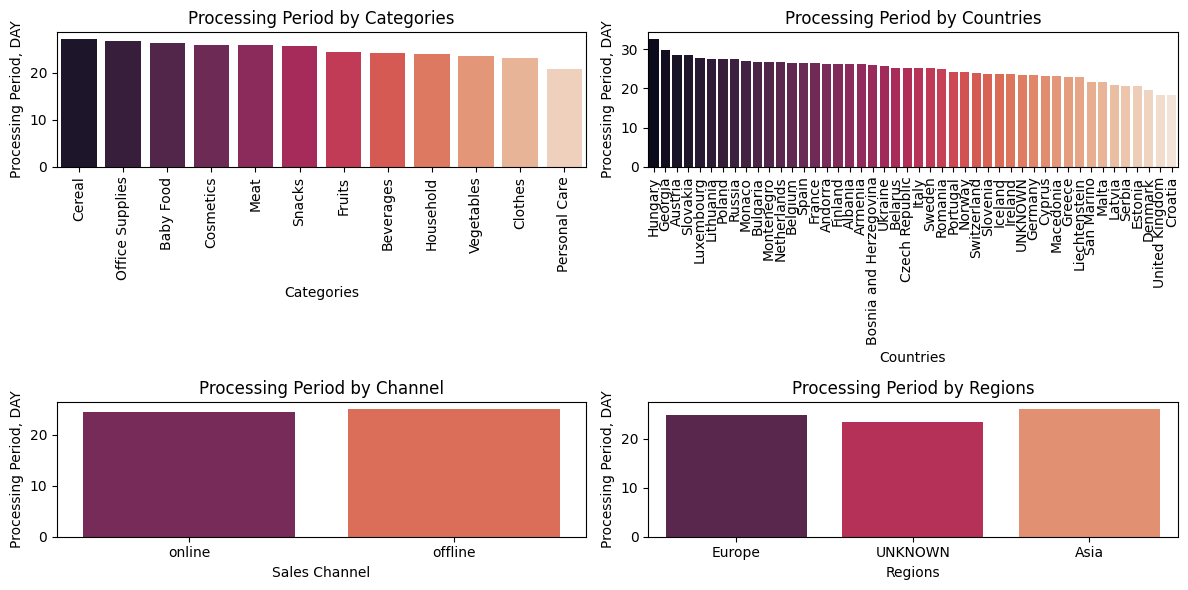

In [ ]:
# Create a figure with 2 rows and 2 columns of subplots
fig, ax = plt.subplots(2, 2, figsize=(12, 6))

#First subplot
order_processing_period_1 = sales_data.groupby('category')['processing_period_days'].mean().sort_values(ascending = False).index
sns.barplot(
    x="category",
    y="processing_period_days",
    data=sales_data,
    estimator=np.mean,
    errorbar=None,
    order=order_processing_period_1,
    palette="rocket",
    ax=ax[0, 0]
)

ax[0, 0].set_title("Processing Period by Categories")
ax[0, 0].set_xlabel("Categories")
ax[0, 0].set_ylabel("Processing Period, DAY")
ax[0, 0].tick_params(axis='x', rotation=90)

# Second subplot
order_processing_period_2 = sales_data.groupby('country')['processing_period_days'].mean().sort_values(ascending = False).index
sns.barplot(
    x="country",
    y="processing_period_days",
    data=sales_data,
    estimator=np.mean,
    errorbar=None,
    order=order_processing_period_2,
    palette="rocket",
    ax=ax[0, 1]
    )
ax[0, 1].set_title("Processing Period by Countries")
ax[0, 1].set_xlabel("Countries")
ax[0, 1].set_ylabel("Processing Period, DAY")
ax[0, 1].tick_params(axis='x', rotation=90)

# Third subplot
sns.barplot(
    x="sales_channel",
    y="processing_period_days",
    data=sales_data,
    estimator=np.mean,
    errorbar=None,
    palette="rocket",
    ax=ax[1, 0]
    )
ax[1, 0].set_title("Processing Period by Channel")
ax[1, 0].set_xlabel("Sales Channel")
ax[1, 0].set_ylabel("Processing Period, DAY")
ax[1, 0].tick_params(axis='x')


# Fourth subplot
sns.barplot(
    x="region",
    y="processing_period_days",
    data=sales_data,
    estimator=np.mean,
    errorbar=None,
    palette="rocket",
    ax=ax[1, 1]
    )
ax[1, 1].set_title("Processing Period by Regions")
ax[1, 1].set_xlabel("Regions")
ax[1, 1].set_ylabel("Processing Period, DAY")
ax[1, 1].tick_params(axis='x')

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()

In [ ]:
pivot_table_for_processing_period_1 = pd.pivot_table(sales_data, values="processing_period_days", index="category", aggfunc=["mean","median"]).sort_values(by=("mean", "processing_period_days"), ascending=False)
print(pivot_table_for_processing_period_1)
pivot_table_for_processing_period_2 = pd.pivot_table(sales_data, values="processing_period_days", index="country", aggfunc=["mean","median"]).sort_values(by=("mean", "processing_period_days"), ascending=False)
print(pivot_table_for_processing_period_2)

                                  mean                 median
                processing_period_days processing_period_days
category                                                     
Cereal                       27.184466                   29.0
Office Supplies              26.707317                   27.0
Baby Food                    26.339286                   28.5
Cosmetics                    25.912281                   28.0
Meat                         25.909091                   25.0
Snacks                       25.543689                   25.0
Fruits                       24.419643                   23.0
Beverages                    24.123967                   23.0
Household                    23.938144                   24.0
Vegetables                   23.491228                   21.0
Clothes                      23.104762                   21.0
Personal Care                20.763158                   20.5
                                         mean                 median
 

# Висновок по періоду обробки замовлення
Розглянувши періоди обробки замовлень у розрізах категорій, країн, регіонів та способу замовлення, можемо сказати, що:
1. Що найшвидше йде доставка замовлень в категорії Засоби особистої гігєни, найдовше обробляються замовлення в категоріях Злаки, Офісне приладдя та Дитяче харчування, а найменший період обробки має категорія Товари особистої гігієни
2. Якщо ж розглядати дату інформацію по країнам, то ми бачимо, що найбільший період доставки в таких країнах, як Угорщина та Грузія, а найменший в Хорватії Та Великій Бритації. Також слід зазначити, що по деяким країнам середній період доставки відрізняється від медіани, наприклад, в Хорватії меліана складає 11 днів, а середній період доставки більше 18 днів, тобто можемо сказати що частіше товар доставляється значно швидше ніж середній показник, аналогічна ситуація в Португалії, при цьому в Угорщині, Фінляндії, Швейцарії та Україні доставка частіше здійснюється довше ніж середній показник по кількості днів
3. Розглянувши період обробки замовлень та доставки залежно від способу покупки, можемо сказати, що швидше є доставка при покупці Онлайн, але різниця не є значною, так само як і доставка при замовленні в країнах Європи швидше відбувається, ніж в країнах Азії, але різниця мінімальна

/tmp/ipykernel_2139/2772677231.py:12: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=sales_data, x="total_profit", y="processing_period_days", palette="rocket", ax=ax[1])


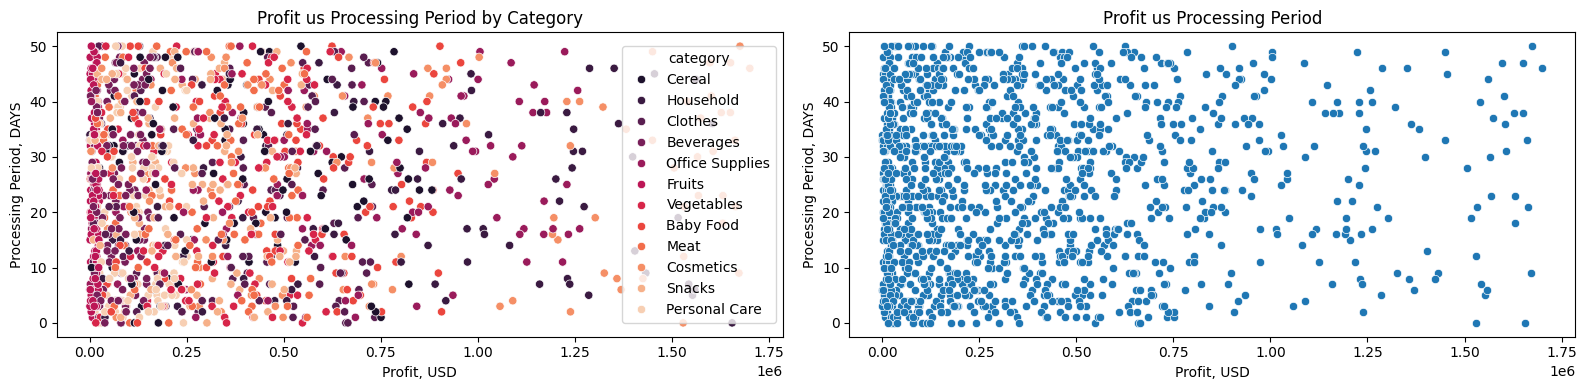

In [ ]:

fig, ax = plt.subplots(1, 2, figsize=(16, 4))

#First subplot
sns.scatterplot(data=sales_data, x="total_profit", y="processing_period_days", hue="category", palette="rocket", ax=ax[0])

ax[0].set_title("Profit us Processing Period by Category")
ax[0].set_xlabel("Profit, USD")
ax[0].set_ylabel("Processing Period, DAYS")


# Second subplot
sns.scatterplot(data=sales_data, x="total_profit", y="processing_period_days", palette="rocket", ax=ax[1])
ax[1].set_title("Profit us Processing Period")
ax[1].set_xlabel("Profit, USD")
ax[1].set_ylabel("Processing Period, DAYS")

# Adjust layout
plt.tight_layout()

# Show plots
plt.show()



Як бачимо, прибуток не залежить від часу обробки замовлення та доставки як в загальному плані, так і в розрізі категорій

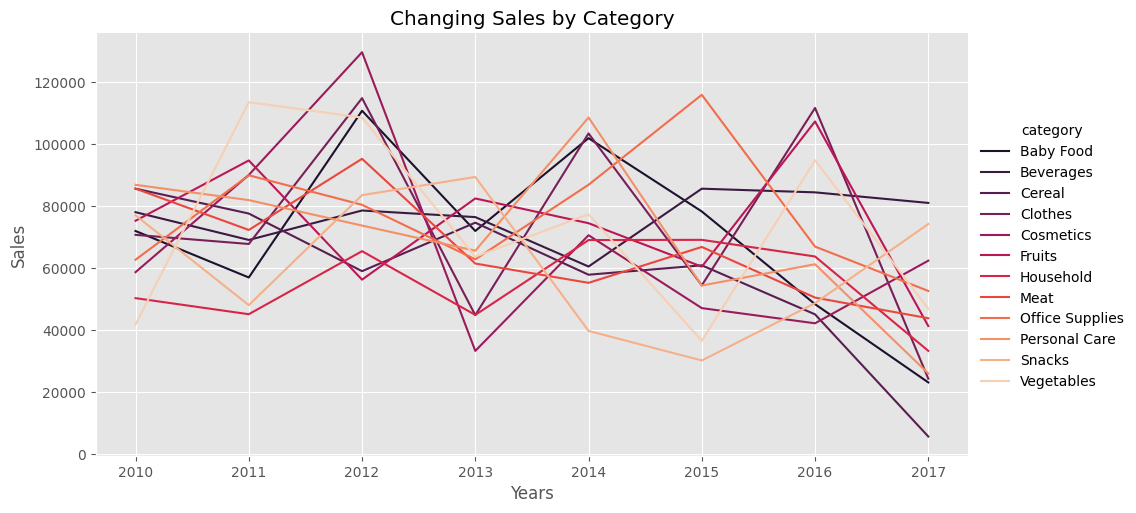

In [ ]:
sales_data["year"] = sales_data["order_date"].dt.year
yearly_sales_by_category = (
    sales_data
    .groupby(["year", "category"])["sold"]
    .sum()
    .reset_index()
)
sns.relplot(
    x="year",
    y="sold",
    kind="line",
    data=yearly_sales_by_category,
    hue="category",
    palette="rocket",
    estimator=np.sum,
    aspect=2
)
plt.title("Changing Sales by Category")
plt.xlabel("Years")
plt.ylabel("Sales")
plt.show()


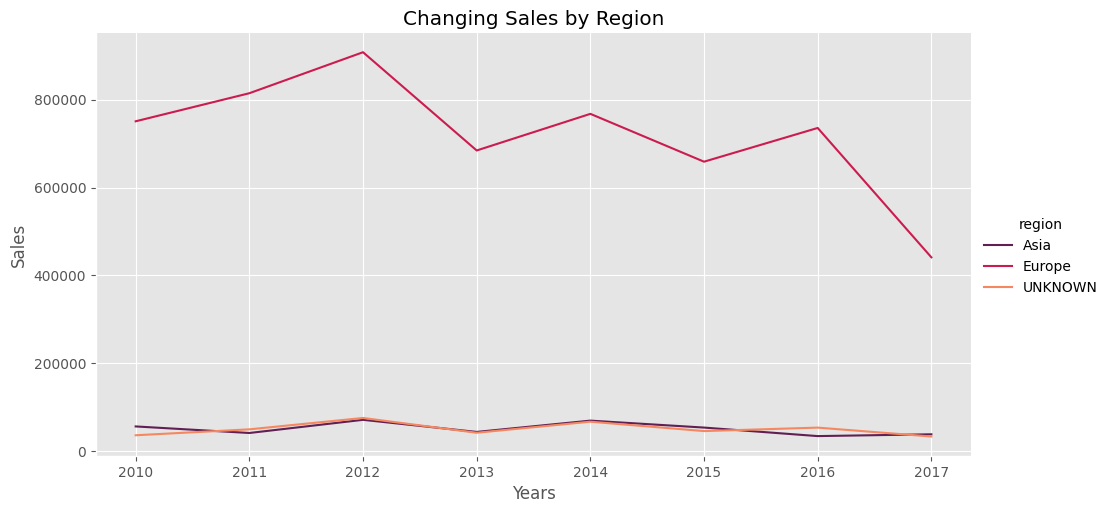

In [ ]:
yearly_sales_by_region = (
    sales_data
    .groupby(["year", "region"])["sold"]
    .sum()
    .reset_index()
)
sns.relplot(
    x="year",
    y="sold",
    kind="line",
    data=yearly_sales_by_region,
    hue="region",
    palette="rocket",
    estimator=np.sum,
    aspect=2
)
plt.title("Changing Sales by Region")
plt.xlabel("Years")
plt.ylabel("Sales")
plt.show()

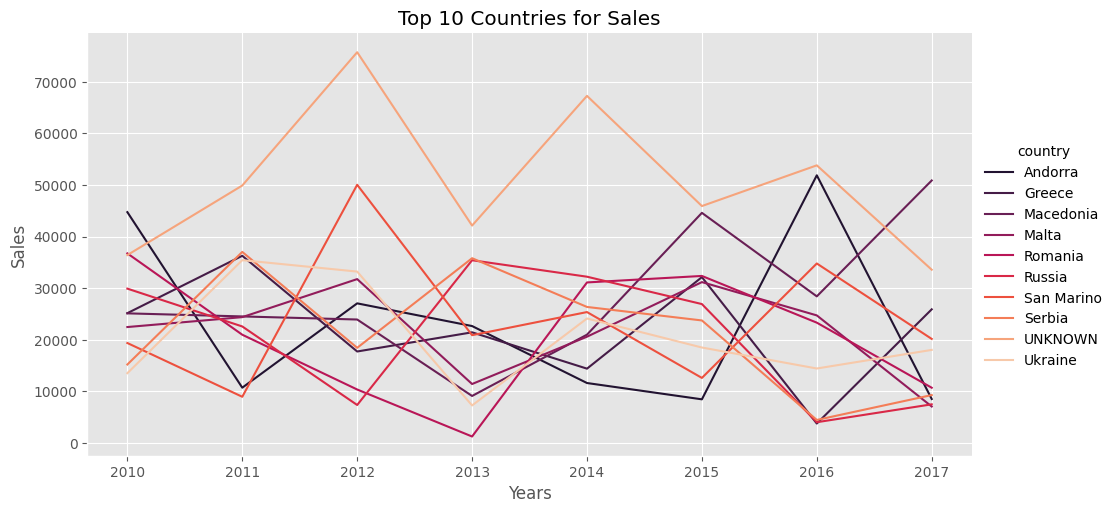

In [ ]:
top_10_countries = (
    sales_data
    .groupby("country")["sold"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)
filtered_data = sales_data[sales_data["country"].isin(top_10_countries)]

yearly_sales_by_region = (
    filtered_data
    .groupby(["year", "country"])["sold"]
    .sum()
    .reset_index()
)
sns.relplot(
    x="year",
    y="sold",
    kind="line",
    data=yearly_sales_by_region,
    hue="country",
    palette="rocket",
    estimator=np.sum,
    aspect=2
)
plt.title("Top 10 Countries for Sales")
plt.xlabel("Years")
plt.ylabel("Sales")
plt.show()

#Динаміка продажів по категоріям, регіонам та ТОП-10 країн

1. Стабільного зростання продажів в досліджуваному періоду не спостерігається.
2. Найбільші продажі в компанії спостерігались в 2012 році
3. Якщо розглядати регіони, то Європа - основний реріон продажів має негативну тенденцію, оскільки вкінці досліджуваного періоду продажі менші, ніж на початку
4. Топ країни по продажам це Україна, Сербія, Сан Маріно, Росія, Румунія, Македонія, Македонія, Мальта, Греція, Андора. При цьому слід зазначити, що Андора та Сан Маріно має тендецію до зростання продажів
5. Серед категорій тенденцію до зростання мають Офісне приладдя, Фрукти, Одяг та Соки, при цьому Снеки, Особиста гігєна та Дитяче харчування мають негативну тенденцію

In [ ]:
sales_data["day_of_week"] = sales_data["order_date"].dt.day_name()
sales_data.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,sold,price,cost,...,region,sub_region,category,total_revenue,total_cost,total_profit,processing_period,processing_period_days,year,day_of_week
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,online,650.0,205.70,117.11,...,Europe,Northern Europe,Cereal,133705.00,76121.50,57583.50,10 days,10.0,2014,Wednesday
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,offline,1993.0,205.70,117.11,...,Europe,Southern Europe,Cereal,409960.10,233400.23,176559.87,0 days,0.0,2016,Thursday
2,101025998,2014-07-18,2014-08-11,M,UNKNOWN,7940,online,4693.0,668.27,502.54,...,UNKNOWN,UNKNOWN,Household,3136191.11,2358420.22,777770.89,24 days,24.0,2014,Friday
3,102230632,2017-05-13,2017-06-13,L,MNE,2455,online,1171.0,109.28,35.84,...,Europe,Southern Europe,Clothes,127966.88,41968.64,85998.24,31 days,31.0,2017,Saturday
4,103435266,2012-08-11,2012-09-18,H,SRB,1270,offline,7648.0,47.45,31.79,...,Europe,Southern Europe,Beverages,362897.60,243129.92,119767.68,38 days,38.0,2012,Saturday


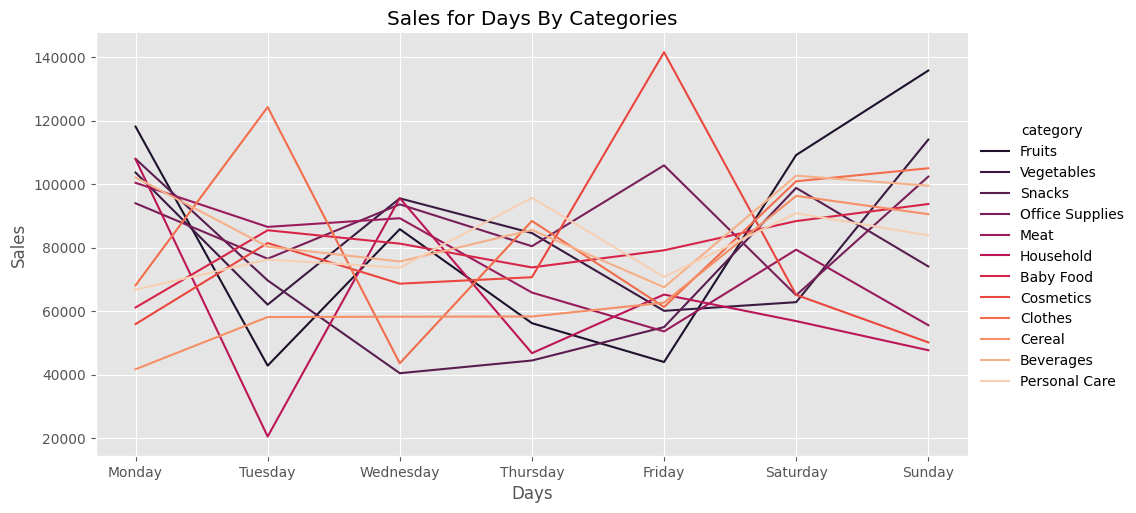

In [ ]:
days_sales_by_category = (
    sales_data
    .groupby(["day_of_week", "category"])["sold"]
    .sum()
    .reset_index()
).sort_values(by="day_of_week", ascending=False)

days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
days_sales_by_category["day_of_week"] = pd.Categorical(
    days_sales_by_category["day_of_week"],
    categories=days_order,
    ordered=True
)
days_sales_by_category = days_sales_by_category.sort_values("day_of_week")
sns.relplot(
    x="day_of_week",
    y="sold",
    kind="line",
    data=days_sales_by_category,
    hue="category",
    palette="rocket",
    estimator=np.sum,
    aspect=2
)
plt.title("Sales for Days By Categories")
plt.xlabel("Days")
plt.ylabel("Sales")
plt.show()

/tmp/ipykernel_2139/3013969457.py:12: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.relplot(


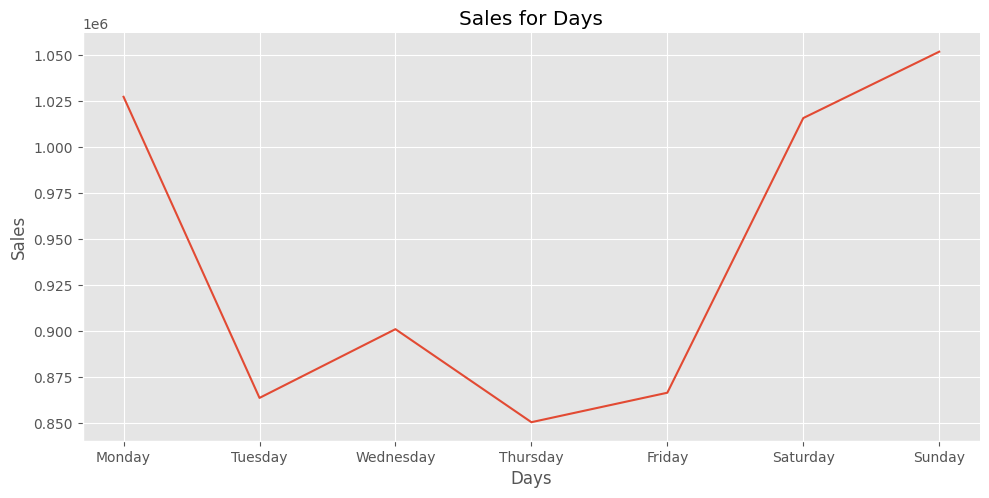

In [ ]:
days_sales = (
    sales_data
    .groupby("day_of_week")["sold"]
    .sum()
    .reset_index()
)
days_sales["day_of_week"] = pd.Categorical(
    days_sales["day_of_week"],
    categories=days_order,
    ordered=True
)
sns.relplot(
    x="day_of_week",
    y="sold",
    kind="line",
    data=days_sales,
    palette="rocket",
    estimator=np.sum,
    aspect=2
)
plt.title("Sales for Days")
plt.xlabel("Days")
plt.ylabel("Sales")
plt.show()

#Чи можна вважати продажі сезонними?

За даними графіка ми бачимо, що загальні продажі найбільші з суботи по понеділок, при цьому в середині тижні є різке падіння, тобто в даному випадку сезонність прослідковується
Якщо взяти до уваги продажі по категоріям, то в більшості категорій відслідковується зростання продажів з пятниці по понеділок. Але слід виділити такі категорії як Дитяче харчування, Мясо та побутова техніка, в яких сезонність не прослідковується взагалі і, здебільшого, день тижня не впливає на продажі